In [1]:
#!apt-get install -y graphviz libgraphviz-dev pkg-config

!pip install pyan3
!pip install graphviz
!pip install pydot
!pip install networkx
!pip install numpy

In [11]:
import pyan
from pyan import anutils

# Simpan original hanya sekali
if not hasattr(anutils.ExecuteInInnerScope, "_original_enter"):
    anutils.ExecuteInInnerScope._original_enter = anutils.ExecuteInInnerScope.__enter__

def _safe_enter(self):
    try:
        return anutils.ExecuteInInnerScope._original_enter(self)
    except ValueError as e:
        if "Unknown scope" in str(e):
            return self
        raise

anutils.ExecuteInInnerScope.__enter__ = _safe_enter

In [47]:
import pyan

# Insert all files in code first version
graphs_1 = pyan.create_callgraph(filenames=['/Users/fitra/Downloads/anaconda_projects/kode disertasi/coba NPD dan contoh/example/app_2.1.0.py'])
# Insert all files in code second version
graphs_2 = pyan.create_callgraph(filenames=['/Users/fitra/Downloads/anaconda_projects/kode disertasi/coba NPD dan contoh/example/app_2.2.0.py'])

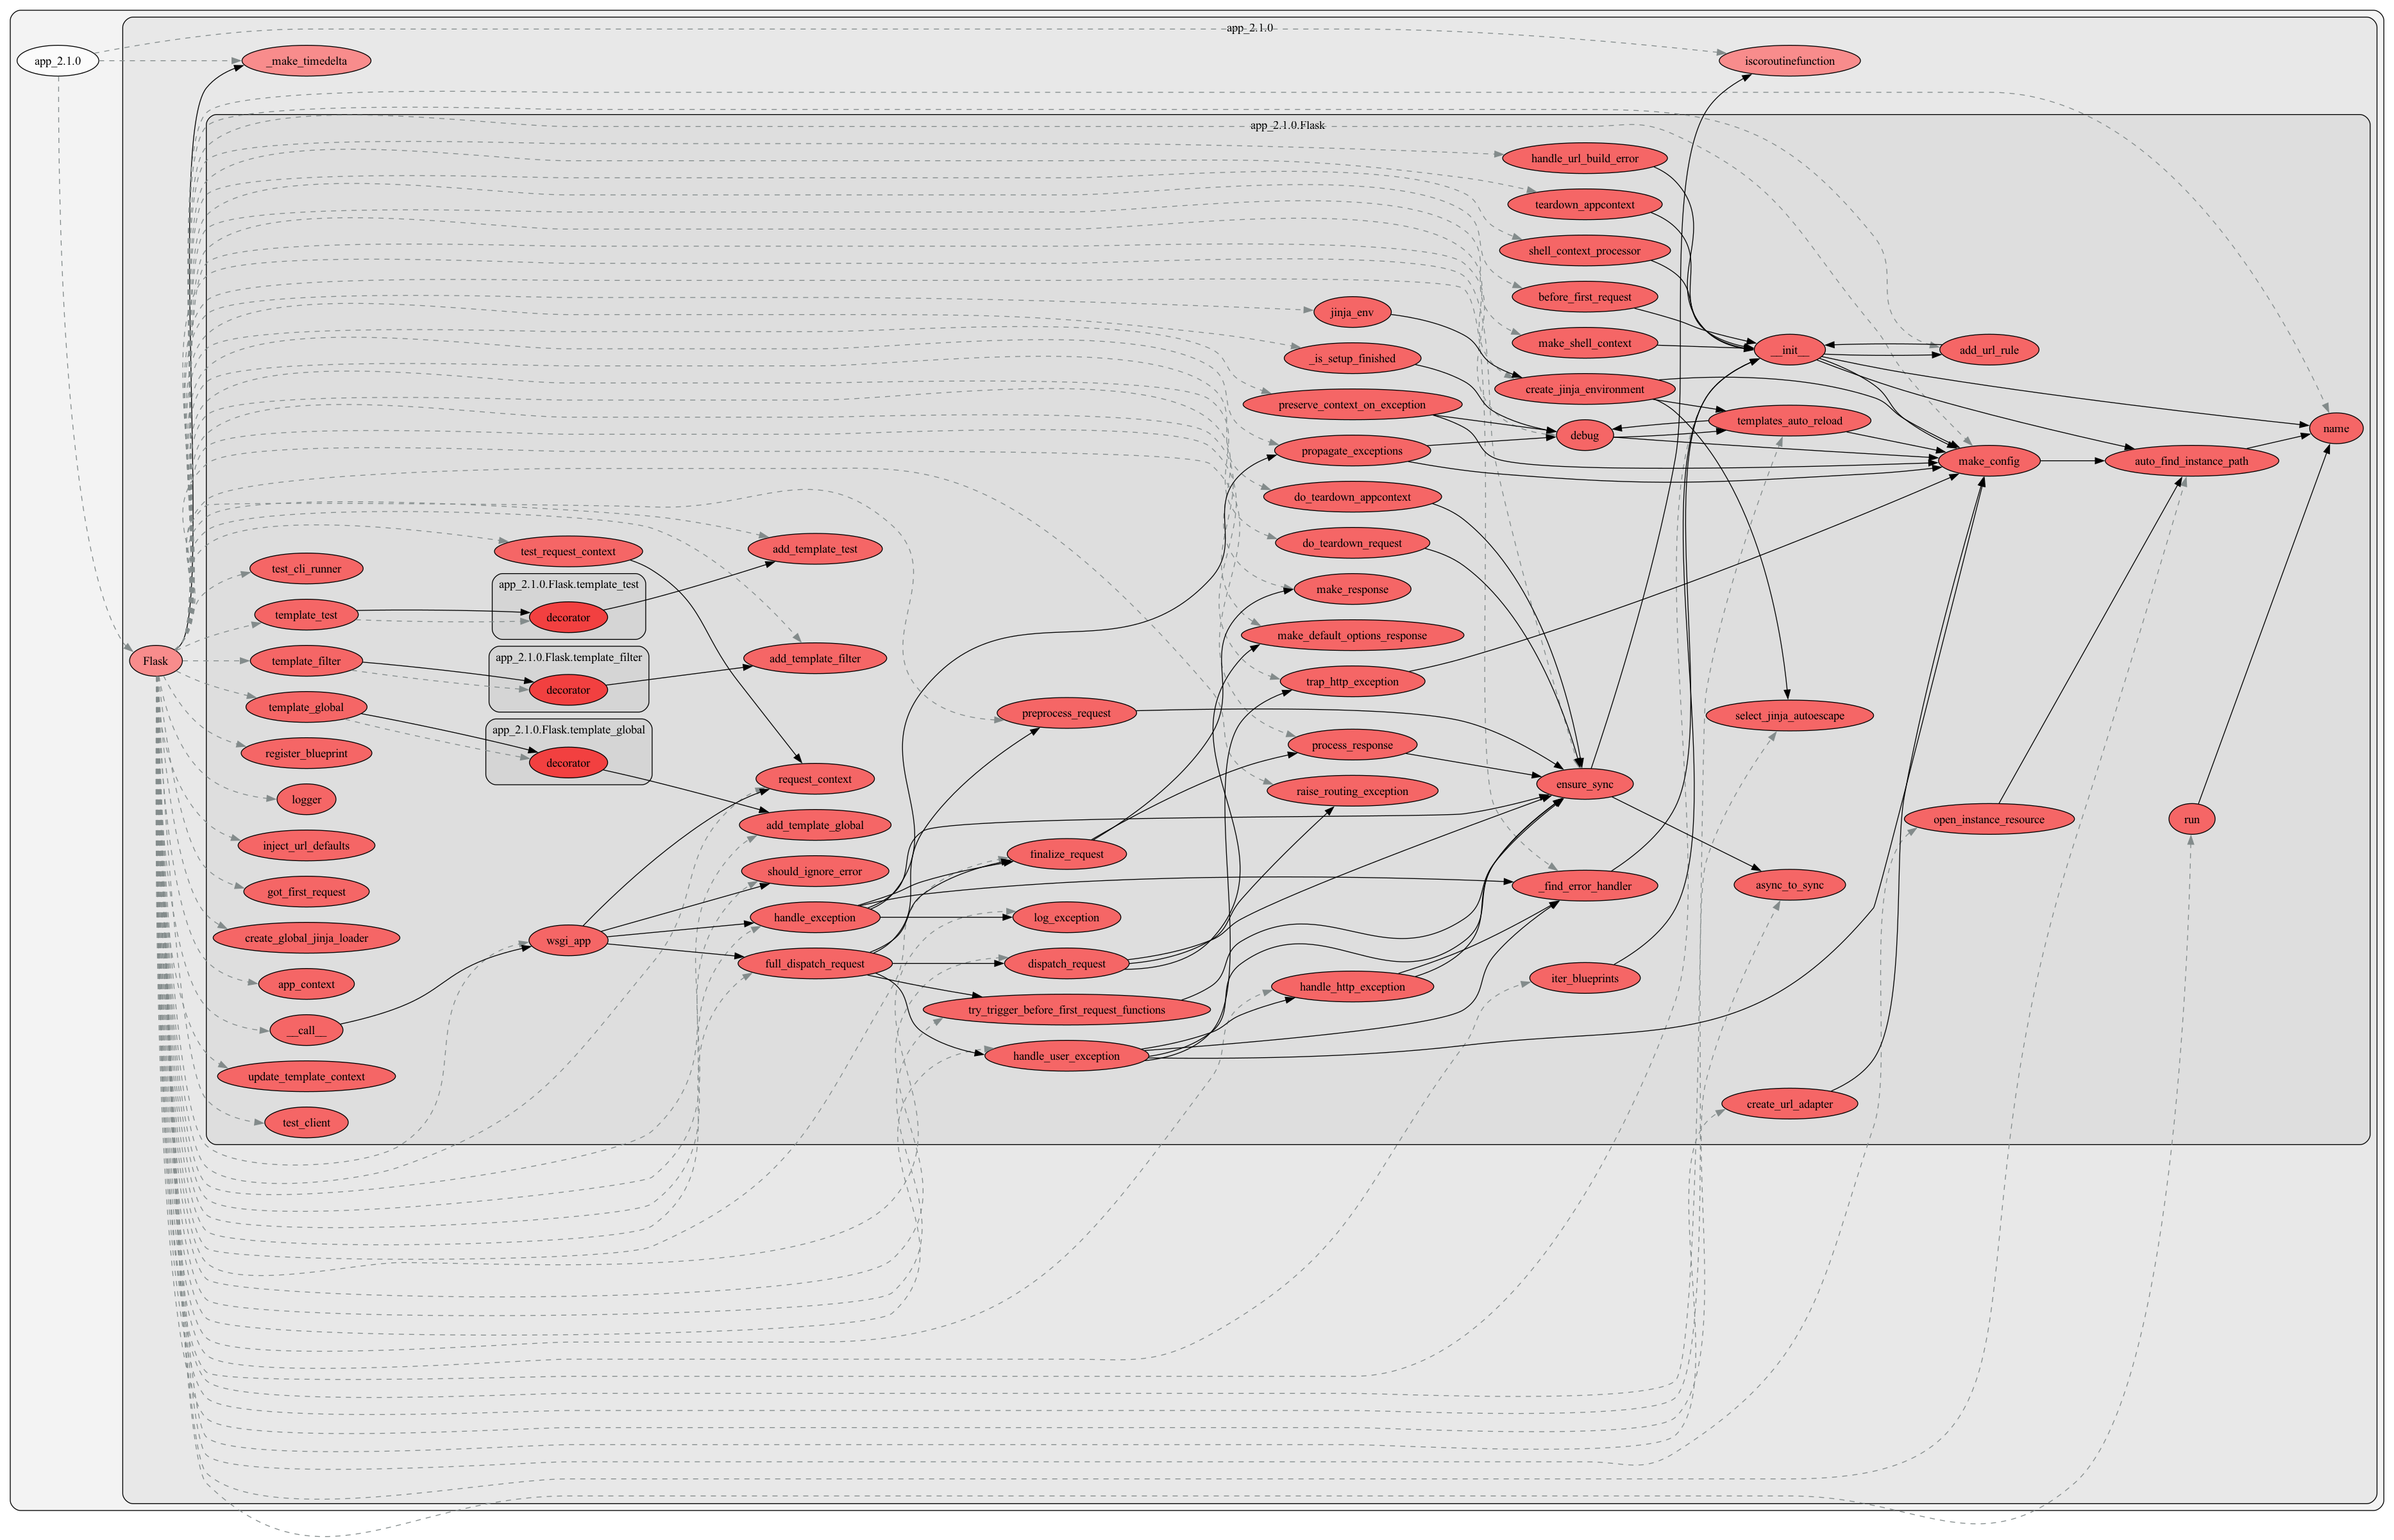

In [48]:
import graphviz
from IPython.display import Image

src_1 = graphviz.Source(graphs_1)
src_2 = graphviz.Source(graphs_2)

src_1.render('my_graph', format='png', view=True)
Image(filename="my_graph.png")

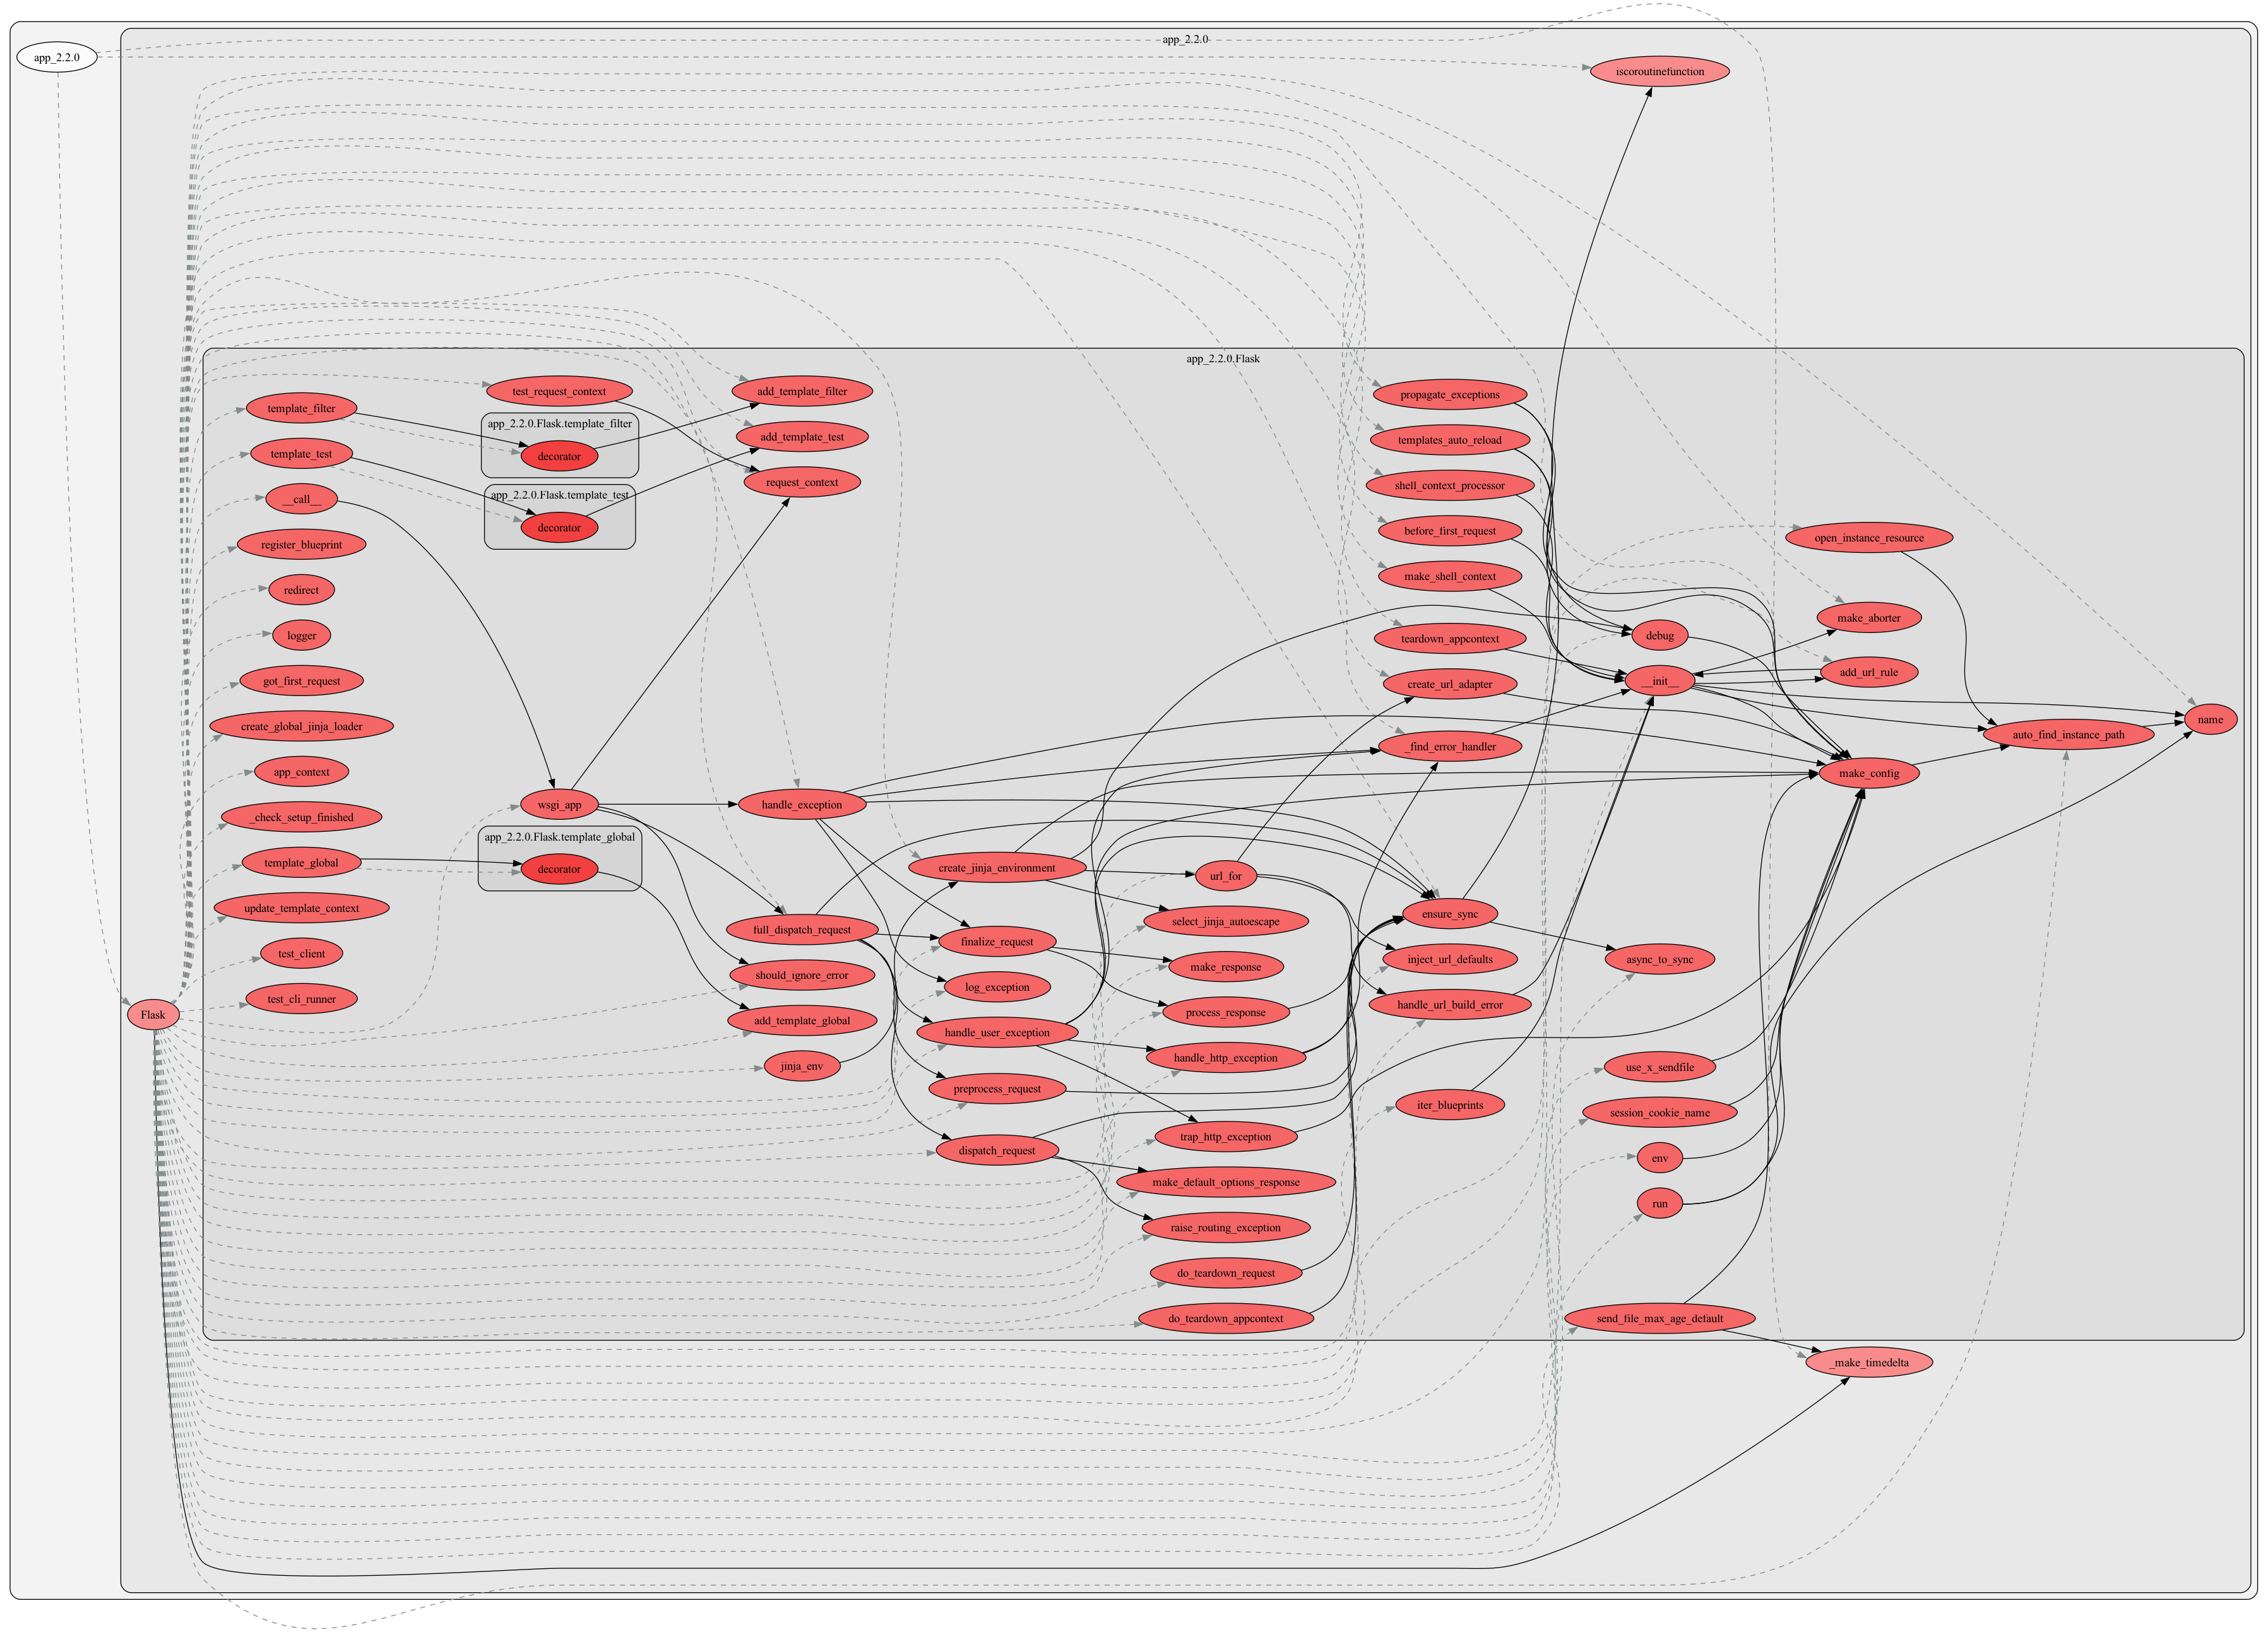

In [49]:
src_2.render('my_graph_2', format='png', view=True)
Image(filename="my_graph_2.png")

In [ ]:
#g perlu dijalankan
import pydot

# Buat wrapper kompatibel untuk get_strict
if pydot.Dot.get_strict.__code__.co_argcount == 1:
    _orig_get_strict = pydot.Dot.get_strict

    def _compat_get_strict(self, *args, **kwargs):
        # Abaikan argumen tambahan; panggil versi asli
        return _orig_get_strict(self)

    pydot.Dot.get_strict = _compat_get_strict

In [ ]:
#g perlu dijalankan
for cls in (pydot.Dot,):
    if hasattr(cls, "get_strict") and cls.get_strict.__code__.co_argcount == 1:
        orig = cls.get_strict
        def _compat(self, *args, __orig=orig, **kwargs):
            return __orig(self)
        cls.get_strict = _compat

In [50]:
import networkx as nx
import pydot

def pydot_to_nx_digraph(pdot_graph):
    """
    Convert a pydot.Dot / pydot.Graph into a NetworkX DiGraph
    tanpa pakai nx.nx_pydot.from_pydot (menghindari bug backend).
    """
    G = nx.DiGraph()

    # Tambah node
    for node in pdot_graph.get_nodes():
        name = node.get_name().strip('"')
        # pydot suka punya node spesial 'node', 'graph', 'edge' -> skip
        if name in ("node", "graph", "edge"):
            continue
        G.add_node(name)

    # Tambah edge
    for edge in pdot_graph.get_edges():
        src = edge.get_source().strip('"')
        dst = edge.get_destination().strip('"')
        G.add_edge(src, dst)

    return G

In [51]:
p1 = pydot.graph_from_dot_data(graphs_1)[0]
p2 = pydot.graph_from_dot_data(graphs_2)[0]

v1 = pydot_to_nx_digraph(p1)
v2 = pydot_to_nx_digraph(p2)

In [52]:
def is_valid_function_node(n):
    name = str(n)

    # buang module root
    if name.count("__") < 2:
        return False

    # buang class container (Flask tanpa method)
    if name.endswith("__Flask"):
        return False

    return True

In [53]:
def build_clean_pyan_graph(dot_str):
    import io
    import networkx as nx
    from networkx.drawing.nx_pydot import read_dot

    G_raw = nx.DiGraph(read_dot(io.StringIO(dot_str)))
    H = nx.DiGraph()

    # ambil node valid
    symbol_nodes = set(n for n in G_raw.nodes if is_valid_function_node(n))

    # add node
    for n in symbol_nodes:
        H.add_node(n)

    # add edge (tidak perlu filter style dulu)
    for u, v in G_raw.edges():
        if u in symbol_nodes and v in symbol_nodes:
            H.add_edge(u, v)

    return H

In [54]:
import io
import networkx as nx
from networkx.drawing.nx_pydot import read_dot

G1_clean = build_clean_pyan_graph(graphs_1)
G2_clean = build_clean_pyan_graph(graphs_2)

print("=== G1 Clean Call Graph ===")
print("Total nodes:", G1_clean.number_of_nodes())
print("Total edges:", G1_clean.number_of_edges())

print("\n=== G2 Clean Call Graph ===")
print("Total nodes:", G2_clean.number_of_nodes())
print("Total edges:", G2_clean.number_of_edges())

print("Sample nodes G1:")
for n in list(G1_clean.nodes())[:10]:
    print(n)

print("Sample nodes G2:")
for n in list(G2_clean.nodes())[:10]:
    print(n)

=== G1 Clean Call Graph ===
Total nodes: 67
Total edges: 74

=== G2 Clean Call Graph ===
Total nodes: 72
Total edges: 80
Sample nodes G1:
app_2__1__0__Flask__template_test
app_2__1__0__Flask__template_filter__decorator
app_2__1__0__Flask__raise_routing_exception
app_2__1__0__Flask__process_response
app_2__1__0__Flask__trap_http_exception
app_2__1__0__Flask__try_trigger_before_first_request_functions
app_2__1__0__Flask__full_dispatch_request
app_2__1__0__Flask___find_error_handler
app_2__1__0__Flask__preserve_context_on_exception
app_2__1__0__Flask__make_default_options_response
Sample nodes G2:
app_2__2__0__Flask__template_filter
app_2__2__0__Flask__teardown_appcontext
app_2__2__0__Flask__preprocess_request
app_2__2__0__Flask__redirect
app_2__2__0__Flask__template_filter__decorator
app_2__2__0__Flask__auto_find_instance_path
app_2__2__0__Flask__trap_http_exception
app_2__2__0__Flask__url_for
app_2__2__0__Flask__update_template_context
app_2__2__0__Flask__add_template_test


In [55]:
import networkx as nx
from collections import defaultdict
import numpy as np

# ==========================
# Fungsi hitung network portrait
# ==========================
def compute_network_portrait(G):
    """
    Hitung network portrait (distribusi jumlah tetangga pada jarak l)
    """
    portrait = defaultdict(lambda: defaultdict(int))

    # Hitung jarak antar node
    for node in G.nodes:
        lengths = nx.single_source_shortest_path_length(G, node)
        count_by_distance = defaultdict(int)
        for target, dist in lengths.items():
            if target != node:
                count_by_distance[dist] += 1

        for l, k in count_by_distance.items():
            portrait[l][k] += 1

    # Flatten ke bentuk {(l,k): count}
    flat = defaultdict(int)
    total = 0
    for l in portrait:
        for k in portrait[l]:
            flat[(l, k)] += portrait[l][k]
            total += portrait[l][k]

    # Normalisasi jadi distribusi probabilitas
    prob_dist = {key: val / total for key, val in flat.items()}
    return prob_dist


# ==========================
# Fungsi align distribusi & hitung JSD
# ==========================
def align_distributions(p1, p2):
    """
    Samakan dimensi vektor distribusi
    """
    all_keys = sorted(set(p1) | set(p2))
    v1 = np.array([p1.get(k, 0.0) for k in all_keys])
    v2 = np.array([p2.get(k, 0.0) for k in all_keys])
    return v1, v2, all_keys


def compute_jsd(P, Q):
    """
    Hitung Jensen-Shannon Divergence (JSD)
    """
    P = P / P.sum()
    Q = Q / Q.sum()
    M = 0.5 * (P + Q)

    eps = 1e-10
    P = np.where(P == 0, eps, P)
    Q = np.where(Q == 0, eps, Q)
    M = np.where(M == 0, eps, M)

    kl_pm = np.sum(P * np.log2(P / M))
    kl_qm = np.sum(Q * np.log2(Q / M))
    jsd = 0.5 * (kl_pm + kl_qm)
    return jsd


# ==========================
# Definisikan graf versi 1 & 2
# ==========================
# Gunakan graf berarah (Directed Graph)
# v1 = nx.DiGraph()
# v1.add_edges_from([
#     ('A', 'B'),
#     ('B', 'C'),
#     ('A', 'D')
# ])

# v2 = nx.DiGraph()
# v2.add_edges_from([
#     ('A', 'B'),
#     ('B', 'E'),
#     ('A', 'D'),
#     ('D', 'C')
# ])


# ==========================
# Hitung network portrait
# ==========================
portrait_v1 = compute_network_portrait(v1)
portrait_v2 = compute_network_portrait(v2)

print("Network Portrait versi 1:")
for k, v in sorted(portrait_v1.items()):
    print(f"{k}: {v:.3f}")

print("\nNetwork Portrait versi 2:")
for k, v in sorted(portrait_v2.items()):
    print(f"{k}: {v:.3f}")


# ==========================
# Hitung JSD antara dua distribusi
# ==========================
P, Q, all_keys = align_distributions(portrait_v1, portrait_v2)
npd_value = compute_jsd(P, Q)

print("\nDistribusi gabungan keys (l,k):", all_keys)
print("Distribusi P (versi 1):", np.round(P, 3))
print("Distribusi Q (versi 2):", np.round(Q, 3))
print(f"\nNilai Network Portrait Divergence (JSD) = {npd_value:.6f}")


Network Portrait versi 1:
(1, 1): 0.276
(1, 2): 0.067
(1, 3): 0.029
(1, 4): 0.019
(1, 5): 0.029
(1, 62): 0.010
(2, 1): 0.095
(2, 2): 0.095
(2, 3): 0.029
(2, 4): 0.095
(2, 7): 0.010
(2, 9): 0.019
(2, 61): 0.010
(3, 1): 0.076
(3, 2): 0.029
(3, 3): 0.010
(3, 4): 0.029
(3, 9): 0.010
(3, 11): 0.010
(4, 1): 0.019
(4, 2): 0.010
(4, 4): 0.010
(4, 11): 0.010
(5, 4): 0.010

Network Portrait versi 2:
(1, 1): 0.263
(1, 2): 0.061
(1, 3): 0.026
(1, 4): 0.018
(1, 5): 0.035
(1, 67): 0.009
(2, 1): 0.140
(2, 2): 0.053
(2, 3): 0.009
(2, 4): 0.053
(2, 5): 0.061
(2, 6): 0.009
(2, 8): 0.009
(2, 10): 0.009
(2, 66): 0.009
(3, 1): 0.079
(3, 2): 0.026
(3, 3): 0.026
(3, 4): 0.018
(3, 5): 0.009
(3, 8): 0.009
(3, 10): 0.009
(4, 2): 0.018
(4, 3): 0.018
(4, 10): 0.009
(5, 2): 0.009
(5, 3): 0.009

Distribusi gabungan keys (l,k): [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 62), (1, 67), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 61), (2, 66), (3, 1), (3, 2), (3, 3), (3, 4), (

In [ ]:
import sys
print("Python executable:", sys.executable)

# install numpy ke environment YANG SAMA dengan kernel
!{sys.executable} -m pip install numpy

In [ ]:
import numpy as np
print("numpy version:", np.__version__)

In [56]:
import networkx as nx
from collections import defaultdict, Counter
import numpy as np

# ==========================
# Enumerate execution paths
# ==========================
def enumerate_execution_paths(G, entry_nodes=None, max_length=None):
    """
    Enumerate simple execution paths in a directed call graph G.
    A path is a sequence of nodes (functions) with no repetition.
    """
    # Default entry nodes: functions labeled as 'main'
    if entry_nodes is None:
        # ENTRY POINT = main function in the callgraph
        entry_nodes = [
            n for n, data in G.nodes(data=True)
            if str(data.get("label")).strip().strip('"').lower() == "main"
        ]
        #Kalau tidak ketemu 'main', fallback ke node tanpa predecessor
        if not entry_nodes:
            entry_nodes = [n for n in G.nodes() if G.in_degree(n) == 0]

    paths = []

    def dfs(path):
        current = path[-1]
        successors = list(G.successors(current))
        # If no successors, the path ends here
        if not successors:
            paths.append(path[:])
            return

        for nxt in successors:
            # Avoid cycles (simple paths only)
            if nxt in path:
                continue
            if max_length is not None and len(path) >= max_length:
                # Stop growing further
                paths.append(path[:])
                continue
            dfs(path + [nxt])

    for src in entry_nodes:
        dfs([src])

    return paths


# ==========================
# Execution-path-based portrait
# ==========================
def compute_execution_path_portrait(G, entry_nodes=None, max_length=None):
    """
    Build a portrait based on execution paths.
    l = path length (number of calls / edges)
    k = number of paths with that length

    Output format: {(l, k): probability}, same shape as compute_network_portrait.
    """
    paths = enumerate_execution_paths(G, entry_nodes=entry_nodes,
                                      max_length=max_length)

    # Path length in edges, not nodes
    length_counts = Counter(len(p) - 1 for p in paths if len(p) > 1)

    portrait = defaultdict(lambda: defaultdict(int))
    total = 0

    for l, count in length_counts.items():
        # l = path length, k = number of paths with that length
        k = count
        # Use k as weight so probability reflects number of paths
        portrait[l][k] += k
        total += k

    if total == 0:
        return {}

    flat = {}
    for l in portrait:
        for k in portrait[l]:
            flat[(l, k)] = portrait[l][k] / total

    return flat


# ==========================
# Compare original NPD vs execution-path NPD
# ==========================
# Assumes v1 and v2 are already defined NetworkX graphs,
# and that compute_network_portrait, align_distributions, and compute_jsd
# have been defined earlier in the notebook.

portrait_v1 = compute_network_portrait(v1)
portrait_v2 = compute_network_portrait(v2)

print("=== Original NPD Portrait (neighbourhood-based) ===")
for key, val in sorted(portrait_v1.items()):
    print(f"{key}: {val:.3f}")

P, Q, all_keys = align_distributions(portrait_v1, portrait_v2)
npd_original = compute_jsd(P, Q)

print("\nKeys (l,k):", all_keys)
print("P (v1):", np.round(P, 3))
print("Q (v2):", np.round(Q, 3))
print(f"\nOriginal Network Portrait Divergence (JSD) = {npd_original:.6f}")

ep_portrait_v1 = compute_execution_path_portrait(v1)
ep_portrait_v2 = compute_execution_path_portrait(v2)

print("\n=== Execution-path-based Portrait ===")
for key, val in sorted(ep_portrait_v1.items()):
    print(f"{key}: {val:.3f}")

P_ep, Q_ep, all_keys_ep = align_distributions(ep_portrait_v1, ep_portrait_v2)
npd_ep = compute_jsd(P_ep, Q_ep)

print("\nKeys (l,k) - execution path:", all_keys_ep)
print("P_ep (v1):", np.round(P_ep, 3))
print("Q_ep (v2):", np.round(Q_ep, 3))
print(f"\nExecution-path-based Divergence (JSD) = {npd_ep:.6f}")


=== Original NPD Portrait (neighbourhood-based) ===
(1, 1): 0.276
(1, 2): 0.067
(1, 3): 0.029
(1, 4): 0.019
(1, 5): 0.029
(1, 62): 0.010
(2, 1): 0.095
(2, 2): 0.095
(2, 3): 0.029
(2, 4): 0.095
(2, 7): 0.010
(2, 9): 0.019
(2, 61): 0.010
(3, 1): 0.076
(3, 2): 0.029
(3, 3): 0.010
(3, 4): 0.029
(3, 9): 0.010
(3, 11): 0.010
(4, 1): 0.019
(4, 2): 0.010
(4, 4): 0.010
(4, 11): 0.010
(5, 4): 0.010

Keys (l,k): [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 62), (1, 67), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 61), (2, 66), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 8), (3, 9), (3, 10), (3, 11), (4, 1), (4, 2), (4, 3), (4, 4), (4, 10), (4, 11), (5, 2), (5, 3), (5, 4)]
P (v1): [0.276 0.067 0.029 0.019 0.029 0.01  0.    0.095 0.095 0.029 0.095 0.
 0.    0.01  0.    0.019 0.    0.01  0.    0.076 0.029 0.01  0.029 0.
 0.    0.01  0.    0.01  0.019 0.01  0.    0.01  0.    0.01  0.    0.
 0.01 ]
Q (v2): [0.263 0.061 0.026 0.018 0.035 0.    0.009 0.14  0.053 

In [36]:
#cek portrait khusus exec path, g harus dijalanakan
#pastikan kalau kasus g0 dan g1, g5, g7 hasilnya list kosong

import io
from networkx.drawing.nx_pydot import read_dot

dot_str_g0 = graphs_1  # string DOT untuk G0
G0 = nx.DiGraph(read_dot(io.StringIO(dot_str_g0)))

dot_str_g1 = graphs_2
G1 = nx.DiGraph(read_dot(io.StringIO(dot_str_g1)))

print("EP portrait G0:", compute_execution_path_portrait(G0))
print("EP portrait G1:", compute_execution_path_portrait(G1))

EP portrait G0: {(1, 2): 0.007905138339920948, (6, 50): 0.1976284584980237, (7, 36): 0.1422924901185771, (3, 18): 0.07114624505928854, (8, 21): 0.08300395256916997, (9, 9): 0.03557312252964427, (4, 45): 0.17786561264822134, (5, 45): 0.17786561264822134, (10, 4): 0.015810276679841896, (2, 22): 0.08695652173913043, (11, 1): 0.003952569169960474}
EP portrait G1: {(1, 2): 0.008849557522123894, (6, 44): 0.19469026548672566, (7, 32): 0.1415929203539823, (5, 39): 0.17256637168141592, (8, 20): 0.08849557522123894, (4, 40): 0.17699115044247787, (3, 13): 0.05752212389380531, (2, 22): 0.09734513274336283, (9, 9): 0.03982300884955752, (10, 4): 0.017699115044247787, (11, 1): 0.004424778761061947}


In [ ]:
conda install pandas

In [ ]:
conda install matplotlib

In [ ]:
import matplotlib.pyplot as plt

# Data for node-only changes
labels = ["G1", "G5", "G7"]
orig = [0.333, 0.333, 0.333]
prop = [0.331, 0.393, 0.442]

plt.figure(figsize=(6,4))
plt.plot(labels, orig, marker='o')
plt.plot(labels, prop, marker='o')

plt.title("Node-only Modifications (No New Paths)")
plt.xlabel("Scenario")
plt.ylabel("Divergence")
plt.ylim(0, 1)
plt.legend(["Original NPD", "Proposed"])
plt.grid()

# ------------------------
# Save figure to PNG
# ------------------------
plt.savefig("node_only_modifications.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Behaviour categories
categories = ["No new path", "New execution paths", "Flow restructuring"]

orig_vals = [
    sum([0.333, 0.333, 0.333]) / 3,      # G1,G5,G7
    sum([0.333, 0.308, 0.667, 0.667]) / 4, # G2,G3,G6,G8
    sum([0.413, 0.308, 0.595, 0.437]) / 4   # G4,G9,G10,G11
]

prop_vals = [
    sum([0.331, 0.393, 0.442]) / 3,
    sum([0.797, 0.797, 0.827, 0.848]) / 4,
    sum([0.595, 0.797, 1.0, 1.0]) / 4
]

plt.figure(figsize=(7,4))
plt.plot(categories, orig_vals, marker='o')
plt.plot(categories, prop_vals, marker='o')
plt.title("Divergence by Behavioural Change Category")
plt.ylabel("Average Divergence")
plt.ylim(0, 1)
plt.grid()
plt.legend(["Original", "Proposed"])

# ------------------------
# Save figure as PNG
# ------------------------
plt.savefig("behaviour_categories.png", dpi=300, bbox_inches='tight')

plt.show()

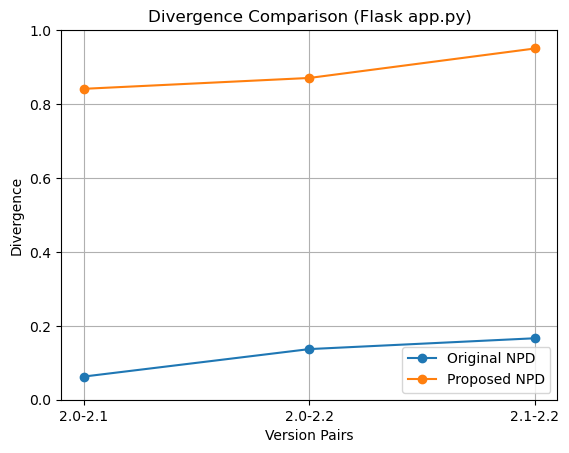

In [57]:
import matplotlib.pyplot as plt

pairs = ["2.0-2.1", "2.0-2.2", "2.1-2.2"]

original = [0.0627, 0.1370, 0.1663]
proposed = [0.8412, 0.8706, 0.9503]

plt.plot(pairs, original, marker='o', label='Original NPD')
plt.plot(pairs, proposed, marker='o', label='Proposed NPD')

plt.ylim(0, 1)
plt.xlabel("Version Pairs")
plt.ylabel("Divergence")
plt.title("Divergence Comparison (Flask app.py)")
plt.legend()
plt.grid()

plt.savefig("flask_app_divergence.png")
plt.show()